In [150]:
import sympy as sm
import numpy as np
import matplotlib.pyplot as plt

# Saddle
$ \dot x = \mu + \alpha x^2$

In [151]:
x,mu,a = sm.symbols('x mu a')
a = 1
exp = mu + a*x**2
de = sm.diff(exp,x)
eq = sm.Eq(exp, 0)
result = sm.solve(eq,x)

[-sqrt(-mu), sqrt(-mu)]
list


<lambdifygenerated-150>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-mu)
<lambdifygenerated-151>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-mu)


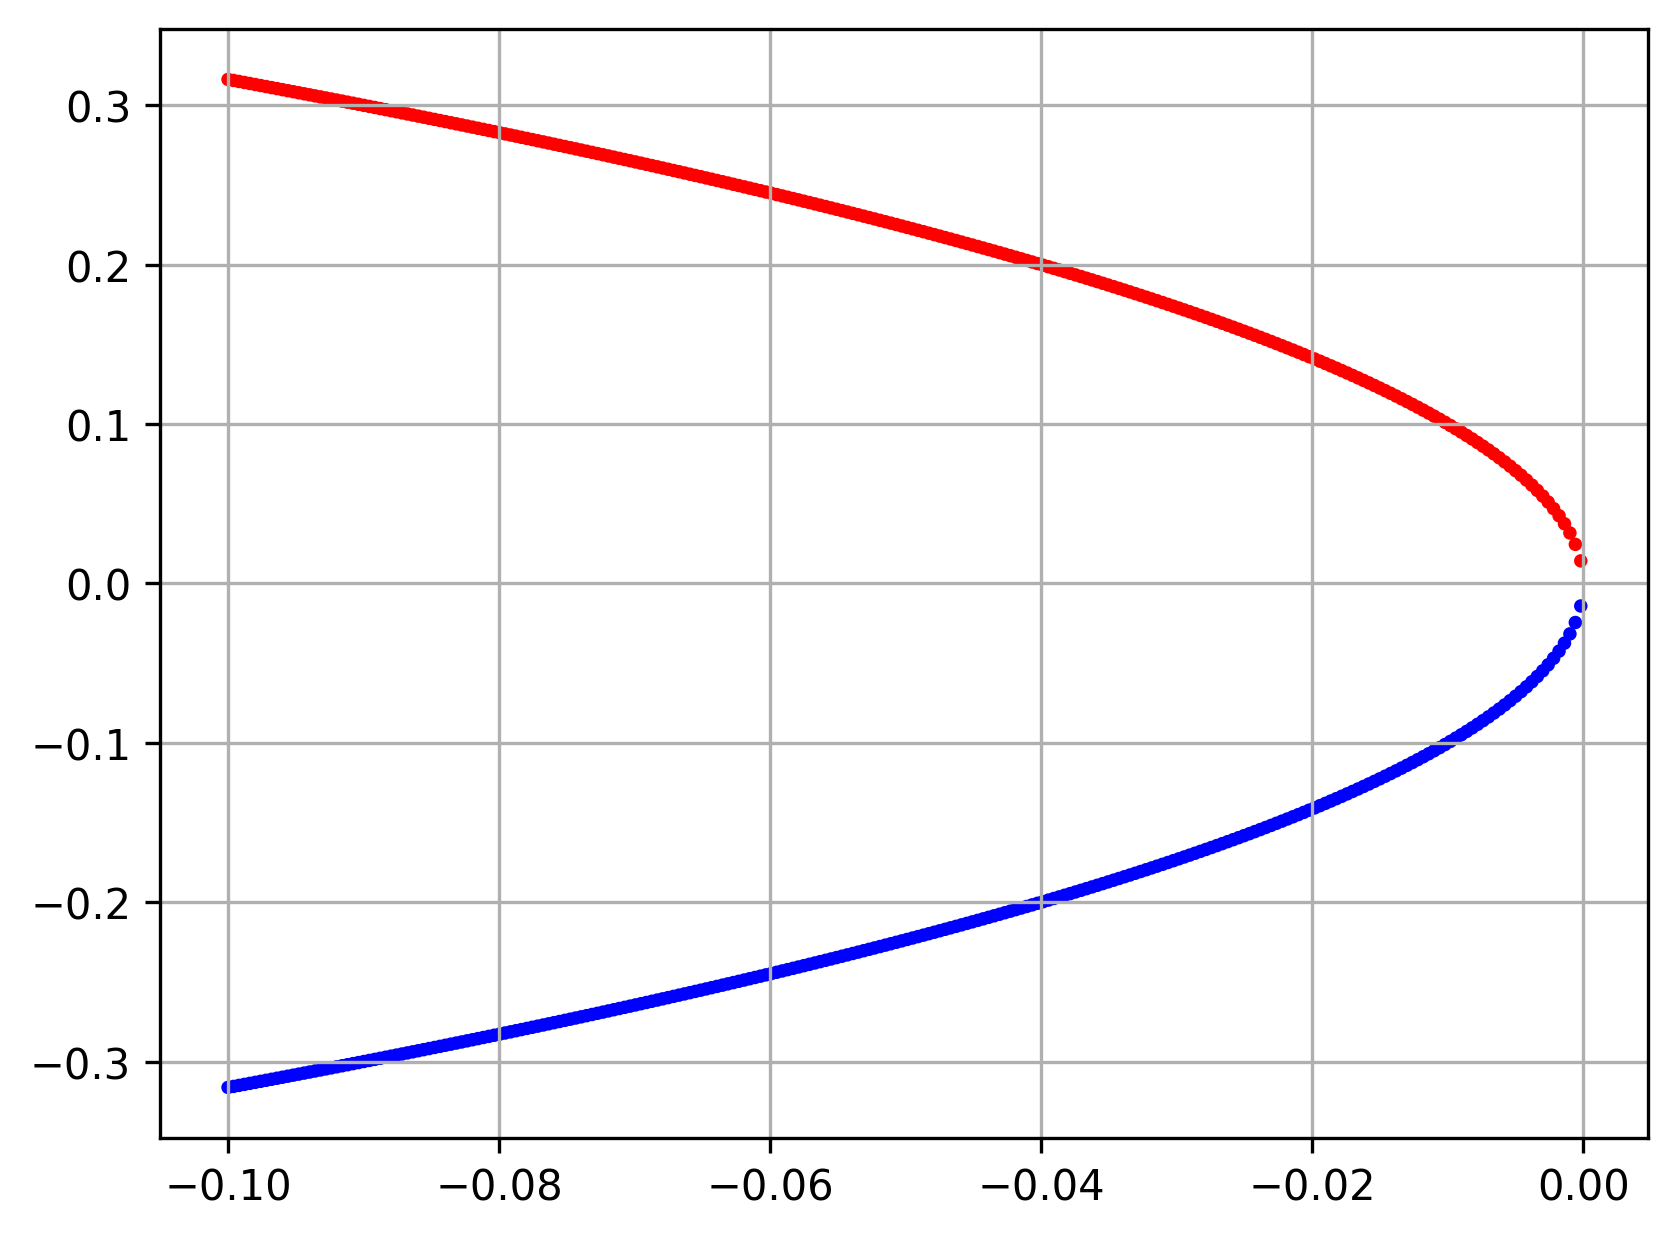

In [152]:
print(result)
print(type(result).__name__)
exprs = result
lmin, lmax = -0.1, 0.1
lmu = np.linspace(lmin,lmax,500)
fs = list(map(lambda x: sm.lambdify(mu, x, "numpy"), exprs))
f_de = sm.lambdify(x, de, "numpy")
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111)
for f in fs:
    points = f(lmu)
    color = np.where(f_de(points) > 0, "red", "blue")
    ax.scatter(lmu, points, s=5, c = color)
plt.grid()
plt.show()

# Pitchfork

$\dot x = \mu x + \alpha x^3$

In [153]:
mu, a, x = sm.symbols("mu a x")
a = 1
exp_pichfork = mu * x + a * x**3
pich_diff = sm.diff(exp_pichfork, x)
f_de = sm.lambdify((x, mu), pich_diff, "numpy")
eq = sm.Eq(exp_pichfork, 0)
sols = sm.solve(eq, x)
pich_diff

mu + 3*x**2

<lambdifygenerated-155>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-mu)
<lambdifygenerated-156>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-mu)


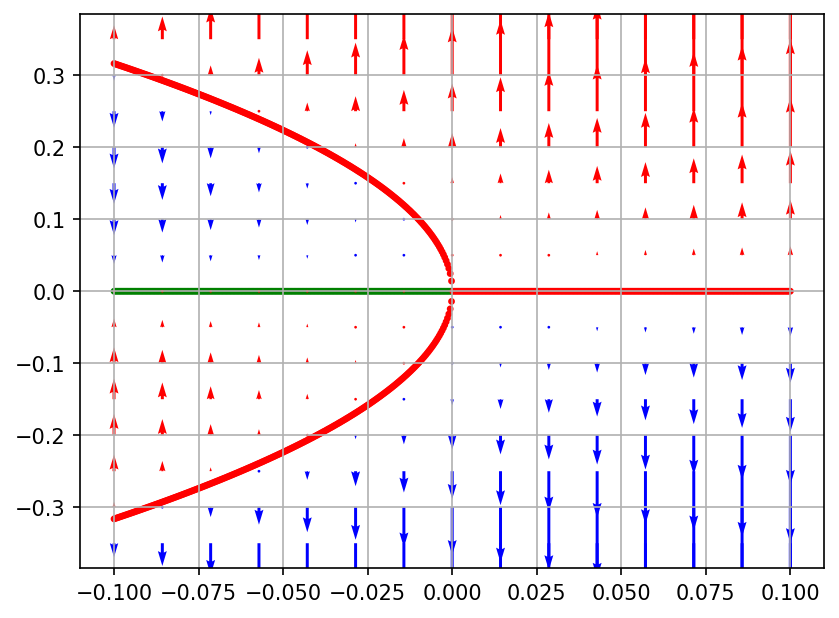

In [154]:
fs = list(map(lambda x : sm.lambdify(mu, x, "numpy"), sols))
fig = plt.figure(dpi=150)
ax = fig.add_subplot(111)
for f in fs:
    y = f(lmu)
    if np.isscalar(y):
        y = np.full_like(lmu, y)
    color = np.where(f_de(y, lmu) > 0, "red", "green")
    ax.scatter(lmu, y, s=5, c=color)

X = np.linspace(lmin,lmax,15)
Y = np.linspace(-0.35,0.35,15)
X, Y = np.meshgrid(X,Y)
V = X * Y + a * Y**3
U = 0
C = np.where(V < 0, 0, 1) 
ax.quiver(X,Y,U,V,C,cmap="bwr")
ax.grid()
plt.show()